### Estimating the Causal Effects of a Growth Mindset Intervention on Academic Performance

**Author**: Varun Mehrotra  (vm749)

**Course**: MSDS 954 567 – Statistical Models and Computing  

In [ ]:
#libraries used:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np



### Data Exploration

In [2]:
# dataset
df = pd.read_csv("data.csv")

#summary of the dataset
print(df.describe())

# Treatment group counts
print(df['z'].value_counts())

# covariate balance check
print(pd.crosstab(df['z'], df['fgen'], normalize='index'))

                  y             z       selfrpt          race        gender  \
count  10391.000000  10391.000000  10391.000000  10391.000000  10391.000000   
mean      -0.020250      0.325666      5.268117      5.223078      1.489943   
std        0.718882      0.468646      1.120765      3.982963      0.499923   
min       -2.123128      0.000000      1.000000      1.000000      1.000000   
25%       -0.487206      0.000000      5.000000      3.000000      1.000000   
50%       -0.056447      0.000000      5.000000      4.000000      1.000000   
75%        0.396832      1.000000      6.000000      5.000000      2.000000   
max        5.118639      1.000000      7.000000     15.000000      2.000000   

               fgen         urban       mindset          test      sch_race  \
count  10391.000000  10391.000000  10391.000000  10391.000000  10391.000000   
mean       0.630931      2.447791     -0.040457      0.054841     -0.089349   
std        0.482576      1.378420      0.969743    

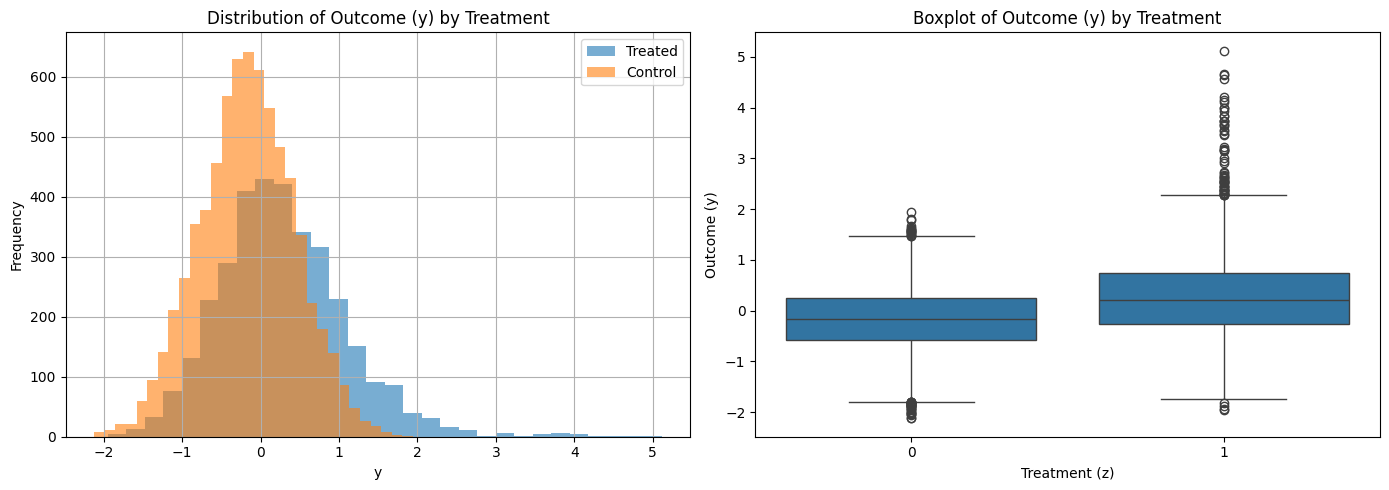

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#histogram for outcome 'y' v/s treatment group
df[df['z'] == 1]['y'].hist(alpha=0.6, bins=30, label='Treated', ax=axes[0])
df[df['z'] == 0]['y'].hist(alpha=0.6, bins=30, label='Control', ax=axes[0])
axes[0].set_title("Distribution of Outcome (y) by Treatment")
axes[0].set_xlabel("y")
axes[0].set_ylabel("Frequency")
axes[0].legend()

#boxplot for outcome 'y' v/s treatment group
sns.boxplot(data=df, x='z', y='y', ax=axes[1])
axes[1].set_title("Boxplot of Outcome (y) by Treatment")
axes[1].set_xlabel("Treatment (z)")
axes[1].set_ylabel("Outcome (y)")

plt.tight_layout()
plt.show()

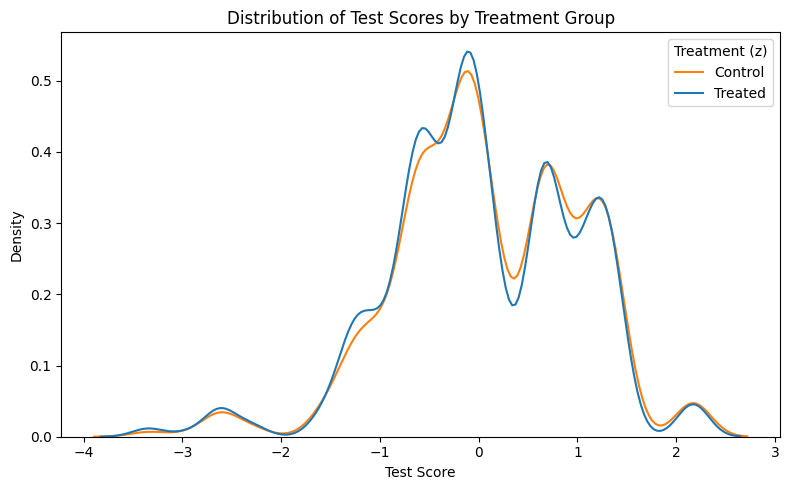

In [ ]:
#i) KDE Plot: test scores acc. to the treatment group

#we filter out the non finite values
df_kde = df[np.isfinite(df['test']) & np.isfinite(df['z'])]

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_kde, x='test', hue='z', common_norm=False)
plt.title("Distribution of Test Scores by Treatment Group")
plt.xlabel("Test Score")
plt.ylabel("Density")
plt.legend(title='Treatment (z)', labels=['Control', 'Treated'])
plt.tight_layout()
plt.show()

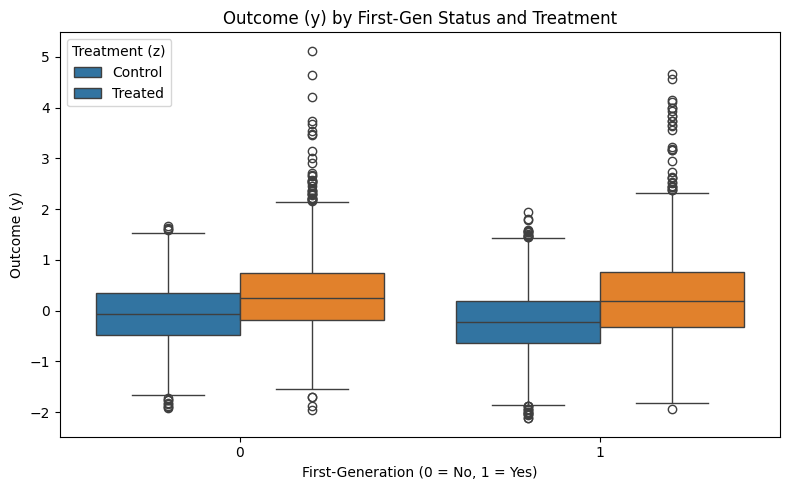

In [ ]:
#ii) Boxplot: Outcome v/s treatment and first gen status

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='fgen', y='y', hue='z')
plt.title("Outcome (y) by First-Gen Status and Treatment")
plt.xlabel("First-Generation (0 = No, 1 = Yes)")
plt.ylabel("Outcome (y)")
plt.legend(title='Treatment (z)', labels=['Control', 'Treated'])
plt.tight_layout()
plt.show()

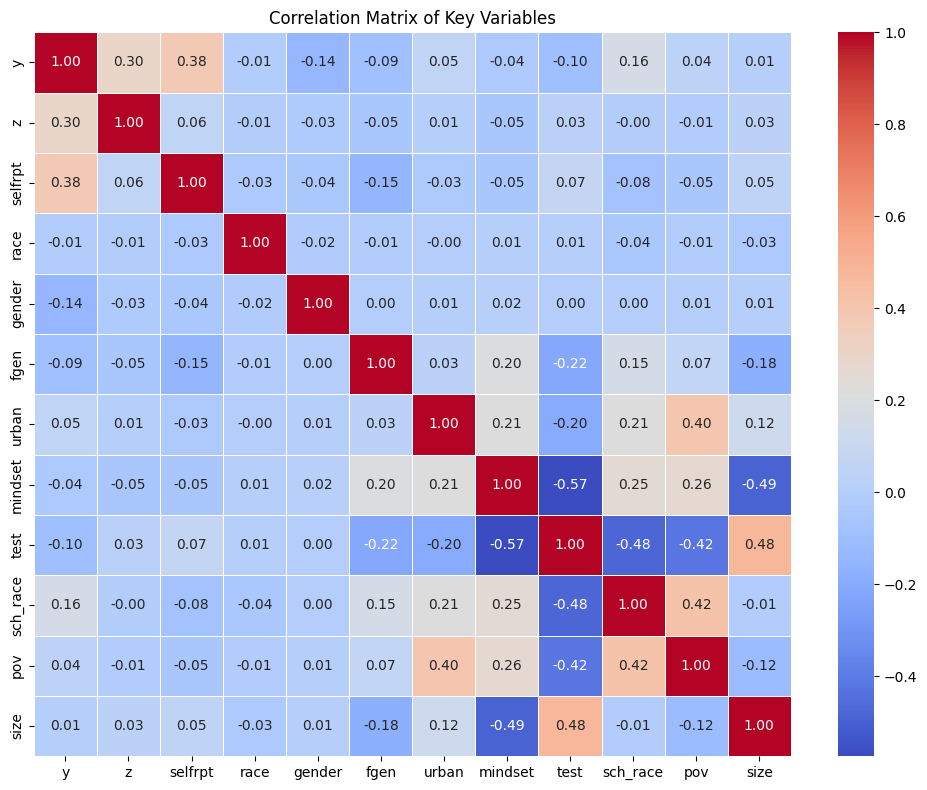

In [ ]:
#iii) Correlation Heatmap

#i selected only the relevant numeric variables
numeric_vars = ['y', 'z', 'selfrpt', 'race', 'gender', 'fgen', 'urban',
                'mindset', 'test', 'sch_race', 'pov', 'size']
df_corr = df[numeric_vars].apply(pd.to_numeric, errors='coerce')

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Variables")
plt.tight_layout()
plt.show()

### Data Analysis

### Summary of methods I will be trying as a part of my causal analysis:


#### 1. Regression Adjustment
- Estimated the average treatment effect (ATE) while controlling for covariates such as `gender`, `race`, `fgen`, `mindset`, and `test`.
- Result: ATE = 0.445 with 95% CI = (0.418, 0.473)

---

#### 2. Stratification by Test Scores
- Divided students into 5 strata (quintiles) based on test scores.
- Estimated within-stratum ATEs and computed a population-weighted average.
- Result: Stratified ATE = 0.465

---

#### 3. Regression with Interaction Terms
- Extended the regression model to include:
  - `z * fgen` (treatment × first-gen status)
  - `z * test` (treatment × prior test scores)
- Main effect of treatment remained strong: ATE = 0.460

---

#### 4. Separate Regressions by Test Score Stratum
- Fitted independent regression models within each test score stratum.
- Estimated treatment effects by stratum:
  - Stratum 1: 0.79
  - Stratum 2: 0.34
  - Stratum 3: 0.64
  - Stratum 4: 0.31
  - Stratum 5: 0.16
- Suggests greater impact for lower-achieving students.

---

#### 5. Covariate Balance Assessment
- Calculated Standardized Mean Differences (SMD) for covariates:
  - `gender`: -0.054
  - `race`: -0.014
  - `fgen`: -0.096
  - `mindset`: -0.098
  - `test`:    0.060
- All values well below the 0.1 threshold, indicating good pre-treatment balance.

---

#### 6. Regression with School Fixed Effects
- Controlled for unobserved school-level variation using `C(schoolid)` as a fixed effect.
- Result: ATE = 0.443

---

In [8]:
#Regression Adjustment
#formula for regression:
reg_formula = "y ~ z + gender + race + fgen + mindset + test"

#OLS model
reg_model = smf.ols(formula=reg_formula, data=df).fit()

#extract ATE from the coefficient of 'z'
ate_regression = reg_model.params['z']
ci_regression = reg_model.conf_int().loc['z']


In [9]:
#Stratification by test score

#create 5 strata based on quantiles of test scores
df['test_stratum'] = pd.qcut(df['test'], q=5, labels=False)

#compute ATE within each stratum
stratum_effects = []
stratum_weights = []


In [10]:
for stratum in sorted(df['test_stratum'].unique()):
    subset = df[df['test_stratum'] == stratum]
    treated = subset[subset['z'] == 1]['y']
    control = subset[subset['z'] == 0]['y']
    
    if len(treated) > 0 and len(control) > 0:
        ate_k = treated.mean() - control.mean()
        weight_k = len(subset) / len(df)
        stratum_effects.append(ate_k * weight_k)
        stratum_weights.append(weight_k)

#weighted average of stratum-specific effects = post-stratified ATE
ate_stratified = np.sum(stratum_effects)

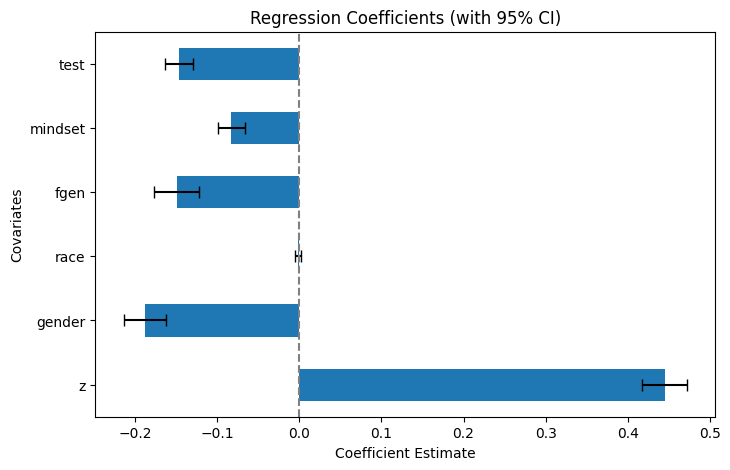

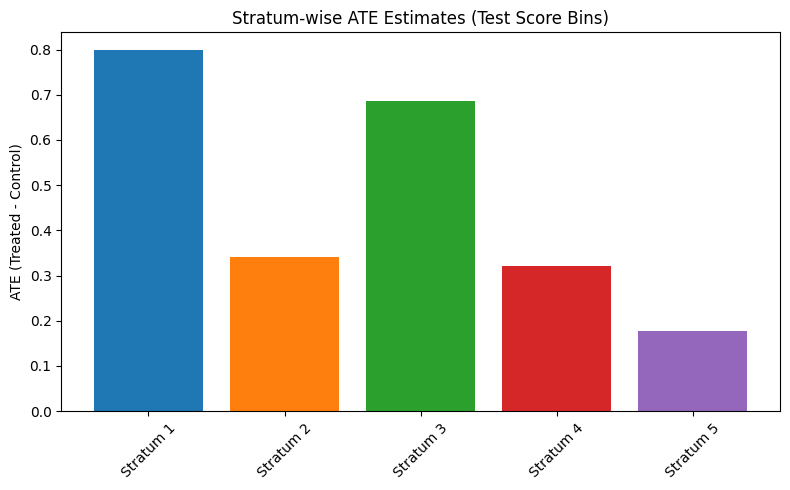

              Coef.  Std.Err.          t          P>|t|    [0.025    0.975]
Intercept  0.223008  0.024808   8.989500   2.915278e-19  0.174380  0.271635
z          0.445066  0.014011  31.765113  2.068545e-211  0.417601  0.472530
gender    -0.188457  0.013116 -14.368194   2.278058e-46 -0.214168 -0.162747
race      -0.001642  0.001646  -0.997435   3.185767e-01 -0.004868  0.001585
fgen      -0.149171  0.013984 -10.667016   1.989577e-26 -0.176583 -0.121759
mindset   -0.082751  0.008296  -9.974609   2.506661e-23 -0.099014 -0.066489
test      -0.147093  0.008623 -17.057891   2.290222e-64 -0.163996 -0.130190

Regression ATE: 0.445
95% CI for ATE: (0.418, 0.473)
Stratified ATE: 0.465


In [ ]:
#Visualizations

#i) Regression Coefficients plot
coeffs = reg_model.params.drop('Intercept')
conf_int = reg_model.conf_int().drop('Intercept')
errors = coeffs - conf_int[0]

fig1, ax1 = plt.subplots(figsize=(8, 5))
coeffs.plot(kind='barh', xerr=errors, capsize=4, ax=ax1)
ax1.axvline(0, linestyle='--', color='grey')
ax1.set_title("Regression Coefficients (with 95% CI)")
ax1.set_xlabel("Coefficient Estimate")
ax1.set_ylabel("Covariates")


#ii) Stratified ATE plot
stratum_labels = [f"Stratum {int(i)+1}" for i in range(len(stratum_effects))]
stratum_means = [df[df['test_stratum'] == i].groupby('z')['y'].mean() for i in range(5)]

fig2, ax2 = plt.subplots(figsize=(8, 5))
for i, means in enumerate(stratum_means):
    ax2.bar(stratum_labels[i], means[1] - means[0], label=f"ATE: {means[1] - means[0]:.3f}")

ax2.set_title("Stratum-wise ATE Estimates (Test Score Bins)")
ax2.set_ylabel("ATE (Treated - Control)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#regression output summary
print(reg_model.summary2().tables[1])

#output for ATEs and CI
print(f"\nRegression ATE: {ate_regression:.3f}")
print(f"95% CI for ATE: ({ci_regression[0]:.3f}, {ci_regression[1]:.3f})")
print(f"Stratified ATE: {ate_stratified:.3f}")

### Additional visualizations:

In [ ]:
#interaction term for z_fgen and z_test
df['z_fgen'] = df['z'] * df['fgen']
df['z_test'] = df['z'] * df['test']

#i) regrerssion with interaction terms
interaction_formula = "y ~ z + gender + race + fgen + mindset + test + z_fgen + z_test"
interaction_model = smf.ols(formula=interaction_formula, data=df).fit()


In [ ]:
#ii) Regressions by stratum
df['test_stratum'] = pd.qcut(df['test'], q=5, labels=False)
stratum_regression_results = {}

for i in sorted(df['test_stratum'].unique()):
    stratum_df = df[df['test_stratum'] == i]
    model = smf.ols(formula="y ~ z + gender + race + fgen + mindset + test", data=stratum_df).fit()
    stratum_regression_results[f"Stratum {i+1}"] = model.params['z']


In [ ]:
#iii) Covariate Balance: standardized mean diffs
def compute_smd(var):
    treated = df[df['z'] == 1][var]
    control = df[df['z'] == 0][var]
    return (treated.mean() - control.mean()) / np.sqrt((treated.var() + control.var()) / 2)

covariates = ['gender', 'race', 'fgen', 'mindset', 'test']
smds = {var: compute_smd(var) for var in covariates}


In [ ]:
#iv) Regression with School Fixed Effects

df['schoolid'] = df['schoolid'].astype('category')
fixed_effects_model = smf.ols(formula="y ~ z + gender + race + fgen + mindset + test + C(schoolid)", data=df).fit()

interaction_model.params['z'], stratum_regression_results, smds, fixed_effects_model.params['z']

(np.float64(0.45984429904826934),
 {'Stratum 1': np.float64(0.791473685915258),
  'Stratum 2': np.float64(0.3381137565588254),
  'Stratum 3': np.float64(0.6446299763138996),
  'Stratum 4': np.float64(0.30884737141438334),
  'Stratum 5': np.float64(0.15526354557027103)},
 {'gender': np.float64(-0.05434933347159068),
  'race': np.float64(-0.013917810935911865),
  'fgen': np.float64(-0.0960023942744294),
  'mindset': np.float64(-0.09835908606819865),
  'test': np.float64(0.05969618616651486)},
 np.float64(0.4426510490099668))

### Output:

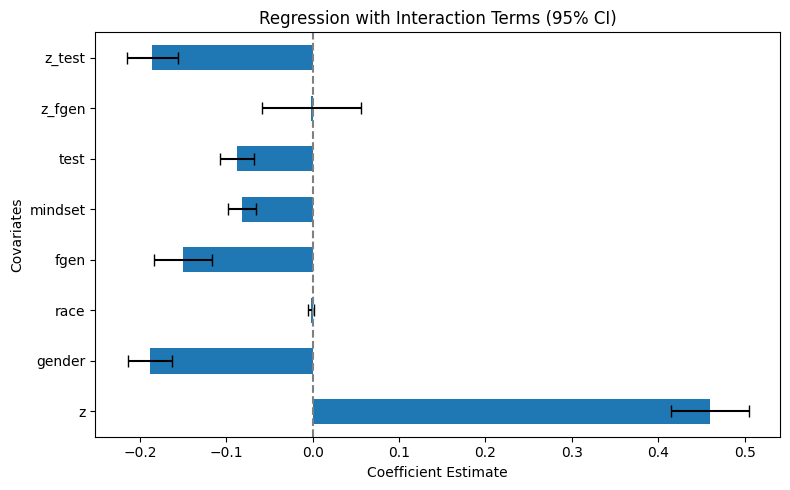

/var/folders/8k/nx6k9cgj6bs996fnr5l7r54r0000gn/T/ipykernel_85103/2929127301.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stratum_names, y=stratum_ates, palette="Blues_d", ax=ax2)


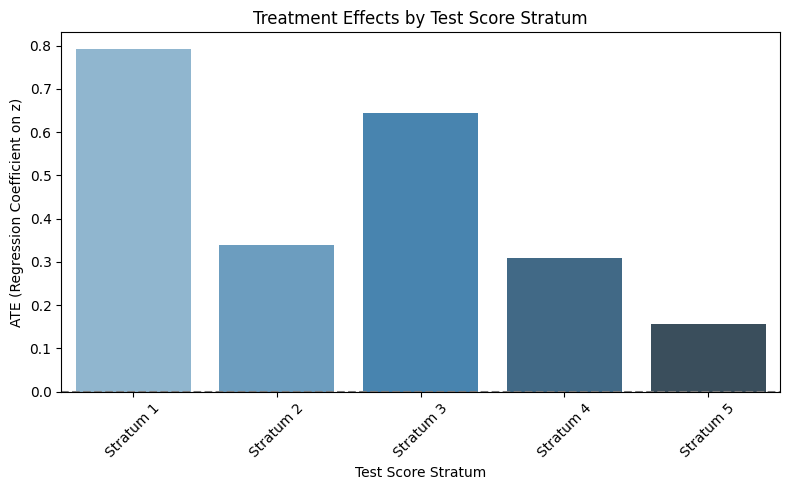

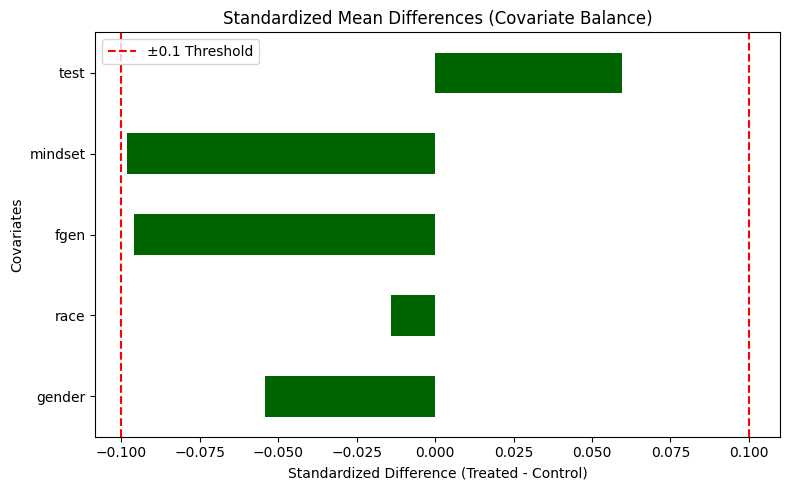

In [ ]:
#i:  Regression with Interaction Terms
interaction_coeffs = interaction_model.params.drop('Intercept')
interaction_conf_int = interaction_model.conf_int().drop('Intercept')
interaction_errors = interaction_coeffs - interaction_conf_int[0]

fig1, ax1 = plt.subplots(figsize=(8, 5))
interaction_coeffs.plot(kind='barh', xerr=interaction_errors, capsize=4, ax=ax1)
ax1.axvline(0, linestyle='--', color='grey')
ax1.set_title("Regression with Interaction Terms (95% CI)")
ax1.set_xlabel("Coefficient Estimate")
ax1.set_ylabel("Covariates")
plt.tight_layout()
plt.show()

#ii:  Separate Regression ATEs by Test Score Stratum
stratum_names = list(stratum_regression_results.keys())
stratum_ates = list(stratum_regression_results.values())

fig2, ax2 = plt.subplots(figsize=(8, 5))
sns.barplot(x=stratum_names, y=stratum_ates, palette="Blues_d", ax=ax2)
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_title("Treatment Effects by Test Score Stratum")
ax2.set_ylabel("ATE (Regression Coefficient on z)")
ax2.set_xlabel("Test Score Stratum")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#iii:  Covariate Balance (Standardized Mean Differences)
smd_series = pd.Series(smds)

fig3, ax3 = plt.subplots(figsize=(8, 5))
smd_series.plot(kind='barh', color='darkgreen', ax=ax3)
ax3.axvline(0.1, linestyle='--', color='red', label='±0.1 Threshold')
ax3.axvline(-0.1, linestyle='--', color='red')
ax3.set_title("Standardized Mean Differences (Covariate Balance)")
ax3.set_xlabel("Standardized Difference (Treated - Control)")
ax3.set_ylabel("Covariates")
ax3.legend()
plt.tight_layout()
plt.show()


In [ ]:
#iv: ATEs and Balance Summary

#ATE from interaction model
print(f"Interaction Model ATE (coefficient on z): {interaction_model.params['z']:.3f}")

#stratum-specific ATEs
print("\nSeparate Regression ATEs by Test Score Stratum:")
for stratum, value in stratum_regression_results.items():
    print(f"  {stratum}: {value:.3f}")

#standardized mean diffs for covariate balance
print("\nStandardized Mean Differences (SMDs) for Covariates:")
for var, smd in smds.items():
    print(f"  {var}: {smd:.3f}")

#ATE from fixed effects regression
fe_ate = fixed_effects_model.params['z']
fe_ci = fixed_effects_model.conf_int().loc['z']
print(f"\nFixed Effects Regression ATE (coefficient on z): {fe_ate:.3f}")
print(f"95% CI: ({fe_ci[0]:.3f}, {fe_ci[1]:.3f})")

Interaction Model ATE (coefficient on z): 0.460

Separate Regression ATEs by Test Score Stratum:
  Stratum 1: 0.791
  Stratum 2: 0.338
  Stratum 3: 0.645
  Stratum 4: 0.309
  Stratum 5: 0.155

Standardized Mean Differences (SMDs) for Covariates:
  gender: -0.054
  race: -0.014
  fgen: -0.096
  mindset: -0.098
  test: 0.060

Fixed Effects Regression ATE (coefficient on z): 0.443
95% CI: (0.417, 0.468)


### Interaction plot: outcome *y* by test score quintile and treatment

/var/folders/8k/nx6k9cgj6bs996fnr5l7r54r0000gn/T/ipykernel_85103/4125892416.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['test_quintile', 'z'])['y'].mean().reset_index()


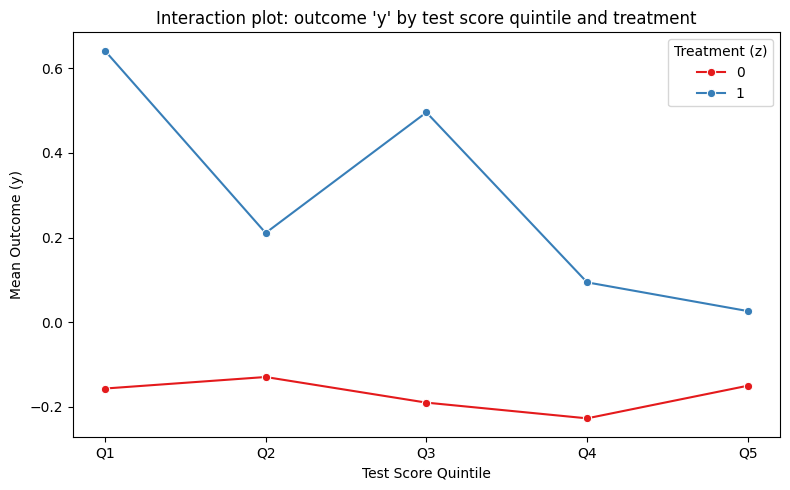

In [ ]:
df['test_quintile'] = pd.qcut(df['test'], q=5, labels=[f'Q{i+1}' for i in range(5)])

#group acc to quintile and treatment to compute the mean outcome
grouped = df.groupby(['test_quintile', 'z'])['y'].mean().reset_index()

#interaction plot b/w test score and treatment effect
plt.figure(figsize=(8, 5))
sns.lineplot(data=grouped, x='test_quintile', y='y', hue='z', marker='o', palette='Set1')
plt.title("Interaction plot: outcome 'y' by test score quintile and treatment")
plt.xlabel("Test Score Quintile")
plt.ylabel("Mean Outcome (y)")
plt.legend(title='Treatment (z)', labels=None)
plt.tight_layout()
plt.show()

## Inference:

- Students in the lowest test score quintile (Q1) benefit the most from the intervention, with average outcomes over 0.6 units higher than their control counterparts

- The treatment remains beneficial across other quintiles, but the effect tapers off as prior performance improves

- For students in the highest quintile (Q5), the difference between treated and control groups is minimal, suggesting a diminishing return of the intervention for already high-performing students

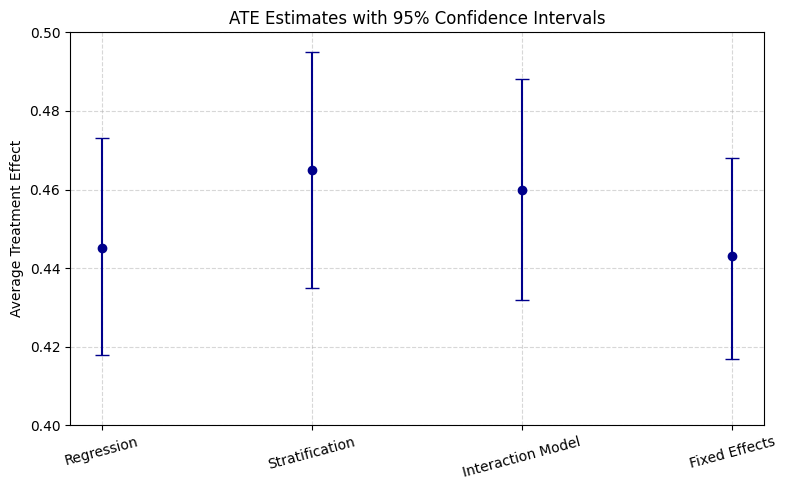

<Figure size 640x480 with 0 Axes>

In [ ]:
#ATE estimates and confidence intervals for each method
methods = ['Regression', 'Stratification', 'Interaction Model', 'Fixed Effects']
ate = [0.445, 0.465, 0.460, 0.443]
ci_lower = [0.418, 0.435, 0.432, 0.417]
ci_upper = [0.473, 0.495, 0.488, 0.468]

results_df = pd.DataFrame({
    'Method': methods,
    'ATE': ate,
    'CI Lower': ci_lower,
    'CI Upper': ci_upper,
    'Error Lower': [a - l for a, l in zip(ate, ci_lower)],
    'Error Upper': [u - a for a, u in zip(ate, ci_upper)]
})

#to plot ATE estimates with error bars
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(results_df['Method'], results_df['ATE'],
            yerr=[results_df['Error Lower'], results_df['Error Upper']],
            fmt='o', capsize=5, color='darkblue')

ax.set_title("ATE Estimates with 95% Confidence Intervals")
ax.set_ylabel("Average Treatment Effect")
ax.set_ylim(0.4, 0.5)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Thank you for your help and guidance this semester! Enjoyed learning this subject alot!!!